# Clase 2 · Análisis exploratorio de datos I

**Módulo 1: Introducción y fundamentos estadísticos** · Diplomado en Ciencia de Datos Aplicada · UTFSM

Objetivos de la sesión: describir una variable con sus tres miradas (centro, dispersión y forma), primero con iris y luego con la EOD, y revisar la calidad de los datos antes de analizarlos.

## 1. Preparación

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Gráficos más nítidos en pantallas de alta resolución
%config InlineBackend.figure_format = "retina"


In [2]:
BASE = (
    "https://raw.githubusercontent.com/daniopitz/diplomado-cdd/"
    "main/datos/eod_stgo/"
)
# Si clonó el repositorio del curso, los datos ya están en su disco:
# BASE = "datos/eod_stgo/"

# Los archivos de la EOD separan columnas con ";" y usan coma decimal.
# low_memory=False lee el archivo completo antes de decidir el tipo de
# cada columna, y evita un aviso de tipos mezclados.
viajes = pd.read_csv(BASE + "viajes.csv", sep=";", decimal=",", low_memory=False)
hogares = pd.read_csv(BASE + "Hogares.csv", sep=";", decimal=",", low_memory=False)

print(viajes.shape, hogares.shape)

(113591, 35) (18264, 21)


## 2. Los conceptos, con iris

iris: 150 flores de tres especies, con cuatro medidas en centímetros (Fisher, 1936). Chico y ordenado: cada resumen se puede verificar a mano. Viene incluido en scikit-learn.

In [3]:
from sklearn.datasets import load_iris

# load_iris() entrega las medidas en iris.data y la especie de cada
# flor en iris.target, como códigos 0, 1 y 2
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

# from_codes traduce cada código a su nombre (0 -> setosa, 1 ->
# versicolor, 2 -> virginica) y deja la columna como categórica
iris_df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Frecuencia y moda

Para una variable cualitativa, el resumen básico es la frecuencia de cada categoría; la moda es la categoría más frecuente.

In [4]:
print(iris_df["species"].value_counts())
print()
print(iris_df["species"].value_counts(normalize=True) * 100)

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

species
setosa        33.333333
versicolor    33.333333
virginica     33.333333
Name: proportion, dtype: float64


Cincuenta de cada especie: un diseño balanceado (y una moda empatada en tres).

### Media y mediana

La media es el promedio: la suma de los valores dividida por el número de datos. La mediana es el valor central: deja el 50% de los datos a cada lado. En una distribución simétrica casi coinciden:

Media:   5.84
Mediana: 5.8


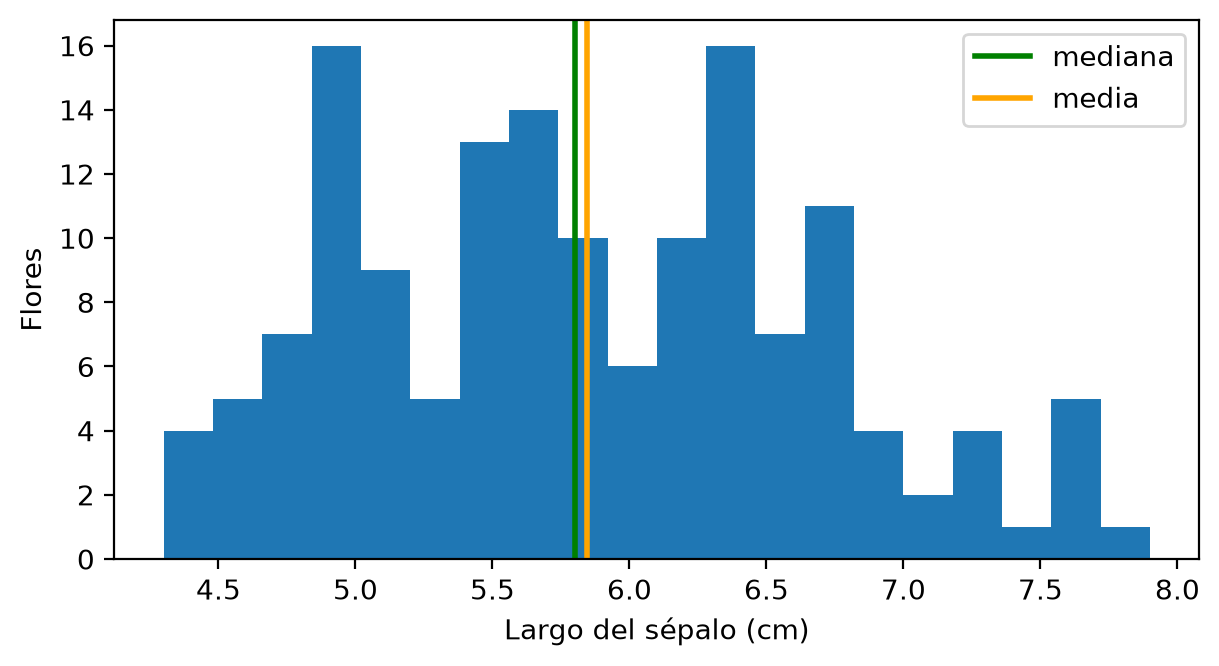

In [5]:
sl = iris_df["sepal length (cm)"]

print("Media:  ", round(sl.mean(), 2))
print("Mediana:", sl.median())

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(sl, bins=20)
# axvline dibuja una línea vertical en el valor indicado; aquí
# marca dónde caen la mediana y la media sobre el histograma
ax.axvline(sl.median(), color="green", lw=2, label="mediana")
ax.axvline(sl.mean(), color="orange", lw=2, label="media")
ax.set_xlabel("Largo del sépalo (cm)")
ax.set_ylabel("Flores")
ax.legend()
plt.show()

### Percentiles y describe

El percentil p es el valor bajo el cual queda el p% de los datos. Los cinco números clásicos son mínimo, Q1, mediana, Q3 y máximo. `quantile` recibe proporciones entre 0 y 1, así que el percentil 25 se pide como `0.25`:

In [6]:
print(sl.quantile([0, 0.25, 0.5, 0.75, 1]))
print()
print(sl.describe().round(2))

0.00    4.3
0.25    5.1
0.50    5.8
0.75    6.4
1.00    7.9
Name: sepal length (cm), dtype: float64

count    150.00
mean       5.84
std        0.83
min        4.30
25%        5.10
50%        5.80
75%        6.40
max        7.90
Name: sepal length (cm), dtype: float64


### Boxplot por grupo

El boxplot comprime esos números en un gráfico: la caja va de Q1 a Q3, la línea interior es la mediana, los bigotes llegan hasta 1,5 veces el IQR y los puntos sueltos son los valores atípicos. Rinde sobre todo al comparar grupos:

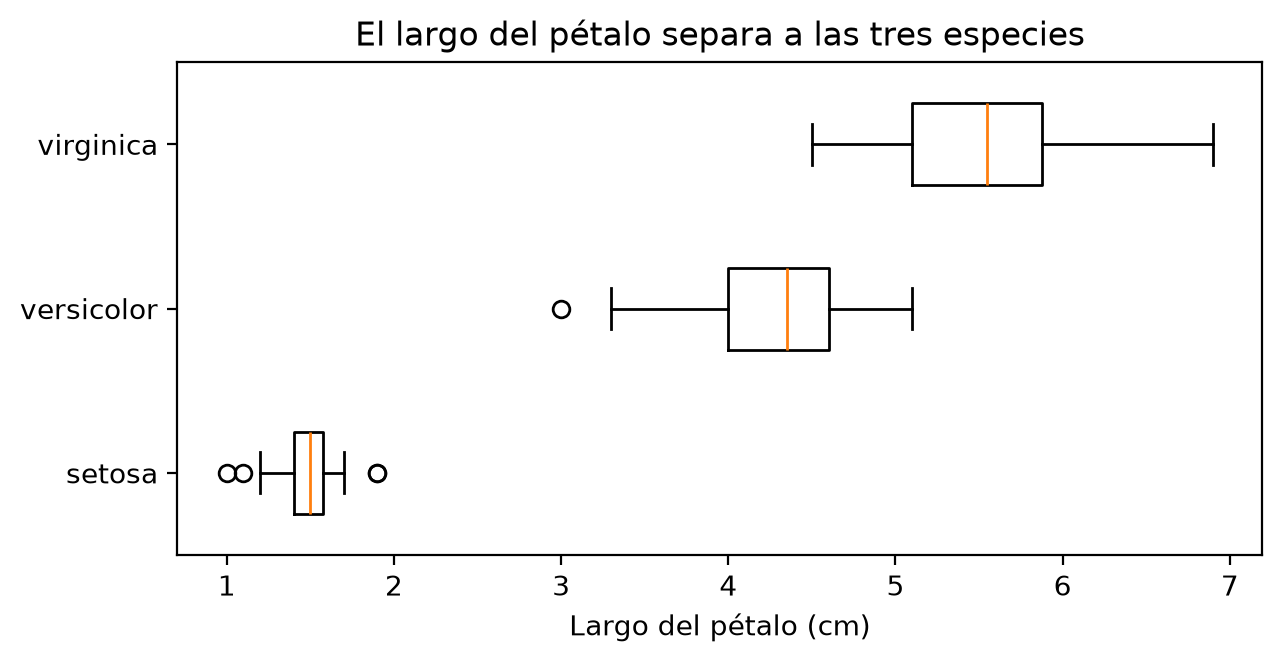

In [7]:
# ax.boxplot espera una lista con los datos de cada grupo. La
# construimos con loc: filtra las filas de una especie y se queda
# con la columna del pétalo; el for lo repite para las tres
especies = ["setosa", "versicolor", "virginica"]
grupos = [iris_df.loc[iris_df["species"] == e, "petal length (cm)"]
          for e in especies]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.boxplot(grupos, orientation="horizontal", tick_labels=especies, widths=0.5)
ax.set_xlabel("Largo del pétalo (cm)")
ax.set_title("El largo del pétalo separa a las tres especies")
plt.show()

## 3. Los conceptos, en la EOD

Los mismos resúmenes, ahora en datos reales. Primero el centro de la duración de los viajes:

In [8]:
tv = viajes["TiempoViaje"]

print("Media:  ", round(tv.mean(), 1), "minutos")
print("Mediana:", tv.median(), "minutos")
# mode() devuelve una Serie, porque puede haber empates; el [0]
# toma el primer valor
print("Moda:   ", tv.mode()[0], "minutos")

Media:   36.9 minutos
Mediana: 30.0 minutos
Moda:    30.0 minutos


Media 36,9 contra mediana 30: asimetría. El caso extremo es el ingreso de los hogares:

Media:   688274
Mediana: 507826


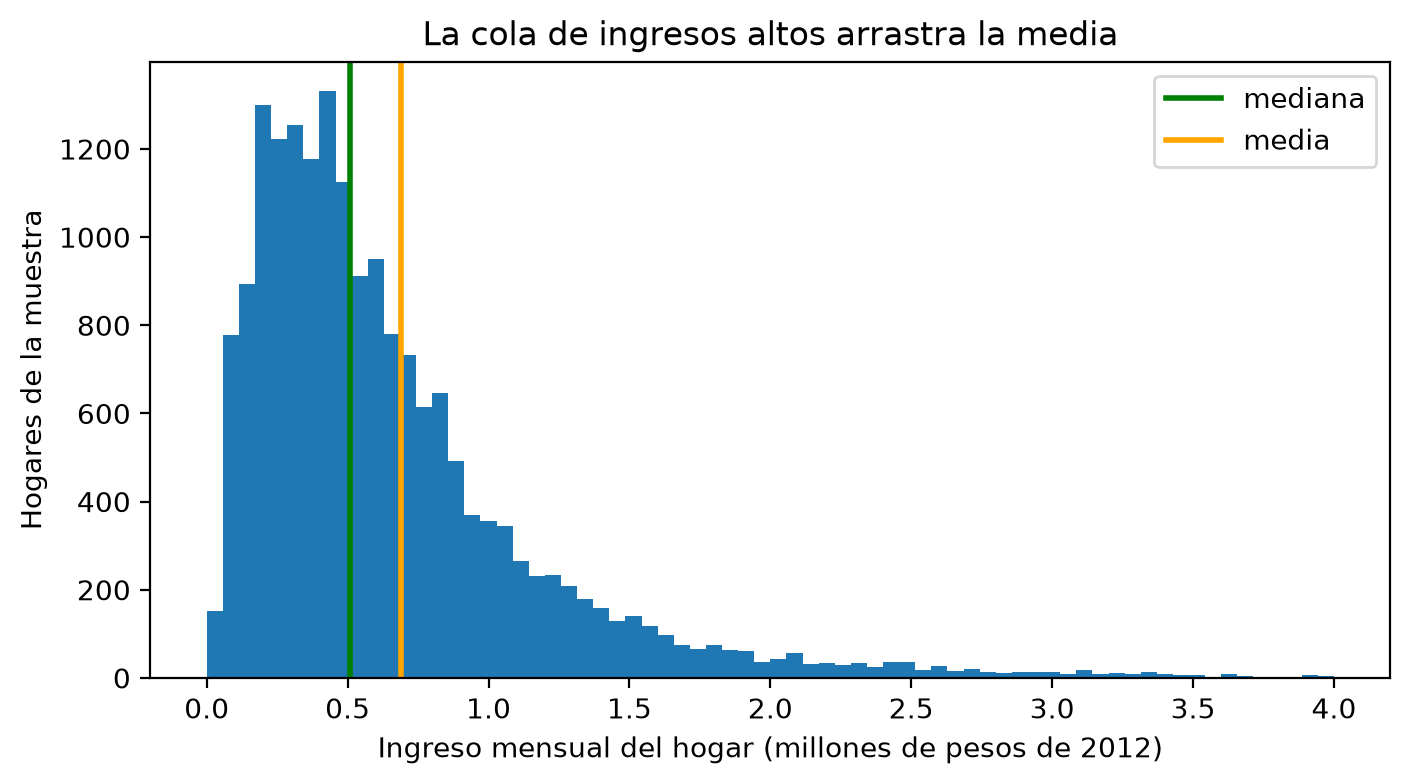

In [9]:
ingreso = hogares["IngresoHogar"]

print("Media:  ", round(ingreso.mean()))
print("Mediana:", round(ingreso.median()))

fig, ax = plt.subplots(figsize=(8, 4))
# Dividir por 1e6 (un millón) deja el eje en millones de pesos;
# range=(0, 4) recorta el histograma en 4 millones para ver la forma
ax.hist(ingreso / 1e6, bins=70, range=(0, 4))
ax.axvline(ingreso.median() / 1e6, color="green", lw=2, label="mediana")
ax.axvline(ingreso.mean() / 1e6, color="orange", lw=2, label="media")
ax.set_xlabel("Ingreso mensual del hogar (millones de pesos de 2012)")
ax.set_ylabel("Hogares de la muestra")
ax.set_title("La cola de ingresos altos arrastra la media")
ax.legend()
plt.show()

La media queda 36% por sobre la mediana.

### Dispersión

El centro no basta: falta saber cuánto se alejan los datos de él. La desviación estándar mide esa distancia típica respecto de la media; el IQR (Q3 menos Q1) es el ancho de la mitad central y no se altera con valores extremos. Para la duración de los viajes:

In [10]:
print("Desviación estándar:", round(tv.std(), 1))
q1, q3 = tv.quantile(0.25), tv.quantile(0.75)
print("Q1, Q3, IQR:        ", q1, q3, q3 - q1)
print()
print(tv.describe().round(1))

Desviación estándar: 36.1
Q1, Q3, IQR:         15.0 50.0 35.0

count    113313.0
mean         36.9
std          36.1
min           0.0
25%          15.0
50%          30.0
75%          50.0
max        1335.0
Name: TiempoViaje, dtype: float64


Y el boxplot por grupo, con el modo de transporte (repaso de los merges de la clase 1). El código tiene tres pasos: unir las tablas para tener el nombre del modo, agrupar las variantes de Bip! en una sola categoría con `where` (recuerde el mnemotécnico: **where conserva el valor donde la condición es verdadera** y reemplaza el resto), y graficar:

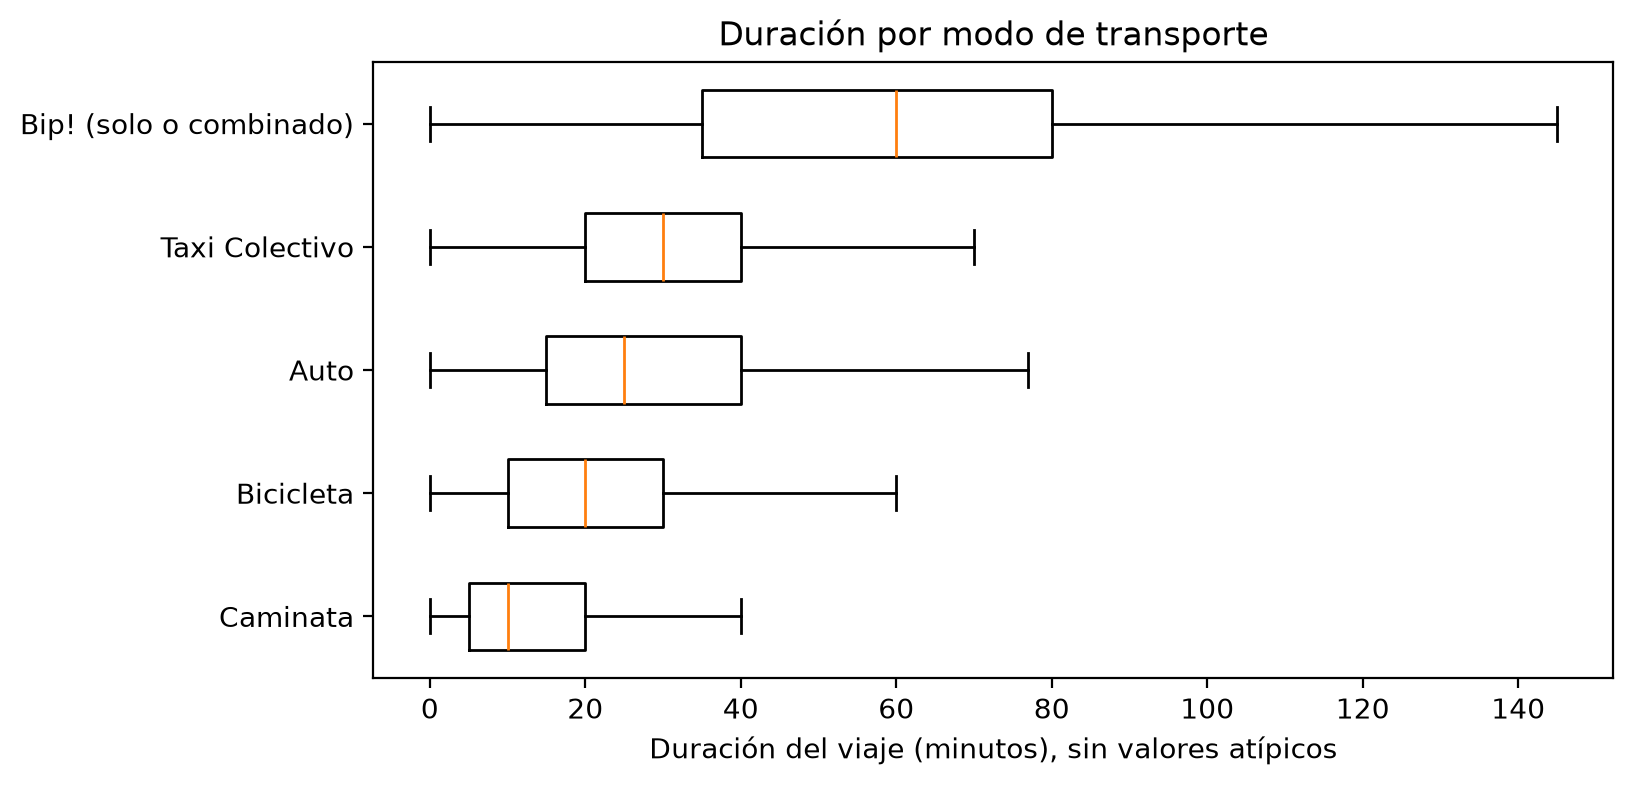

In [11]:
# ViajesDifusion trae el modo de cada viaje como código;
# ModoDifusion traduce ese código a su nombre
modo_por_viaje = pd.read_csv(BASE + "ViajesDifusion.csv", sep=";")
nombres_modo = pd.read_csv(BASE + "tablas_parametros/ModoDifusion.csv", sep=";")
nombres_modo = nombres_modo.rename(columns={"ModoDifusion": "NombreModo"})

# Dos merges encadenados: el modo de cada viaje y luego su nombre
viajes_modo = (viajes
    .merge(modo_por_viaje, on="Viaje")
    .merge(nombres_modo, left_on="ModoDifusion", right_on="ID"))

# where: los nombres que NO empiezan con "Bip!" se conservan;
# los que sí, se reemplazan por la categoría agrupada
viajes_modo["ModoAgrupado"] = viajes_modo["NombreModo"].where(
    ~viajes_modo["NombreModo"].str.startswith("Bip!"),
    "Bip! (solo o combinado)")

orden = ["Caminata", "Bicicleta", "Auto", "Taxi Colectivo",
         "Bip! (solo o combinado)"]
grupos = [viajes_modo.loc[viajes_modo["ModoAgrupado"] == m,
                          "TiempoViaje"].dropna() for m in orden]

fig, ax = plt.subplots(figsize=(8, 4))
# showfliers=False oculta los puntos atípicos, para que las cajas
# se lean sin que la cola larga aplaste la escala
ax.boxplot(grupos, orientation="horizontal", showfliers=False,
           tick_labels=orden, widths=0.55)
ax.set_xlabel("Duración del viaje (minutos), sin valores atípicos")
ax.set_title("Duración por modo de transporte")
plt.show()

## 4. Calidad de los datos

iris viene casi limpio: cero faltantes. Casi, porque hasta el dataset más famoso esconde un problema:

In [12]:
# isna().sum() cuenta los faltantes de cada columna; el segundo
# .sum() suma esos totales en un solo número.
# duplicated() marca las filas repetidas (todas menos la primera
# aparición) y .sum() las cuenta.
print("Faltantes en iris: ", iris_df.isna().sum().sum())
print("Duplicados en iris:", iris_df.duplicated().sum())

Faltantes en iris:  0
Duplicados en iris: 1


Una fila duplicada en 150. En datos reales los problemas son mayores; el checklist es el mismo.

### Valores faltantes en la EOD

In [13]:
print("Filas:          ", len(viajes))
print("Con TiempoViaje:", viajes["TiempoViaje"].count())
print("Faltantes:      ", viajes["TiempoViaje"].isna().sum())

Filas:           113591
Con TiempoViaje: 113313
Faltantes:       278


278 faltantes entre 113.591. Un `NaN` no siempre es error: en los factores de expansión significa "no aplica". Las opciones (eliminar, imputar o dejar que cada cálculo excluya) son todas válidas; lo obligatorio es decidir y documentar.

### Duplicados en la EOD

In [14]:
print("Filas duplicadas:      ", viajes.duplicated().sum())
print("Ids de viaje repetidos:", viajes["Viaje"].duplicated().sum())

Filas duplicadas:       0
Ids de viaje repetidos: 0


Cero en ambos niveles: un hallazgo que descarta una fuente de error.

### Valores sospechosos

In [15]:
# nlargest(10) entrega los 10 valores más grandes de la columna,
# ordenados de mayor a menor: los diez viajes más largos declarados
viajes["TiempoViaje"].nlargest(10)

86757     1335.0
109749    1282.0
45267     1240.0
13755      945.0
27892      855.0
40207      830.0
63807      815.0
110189     815.0
109681     790.0
54524      780.0
Name: TiempoViaje, dtype: float64

Viajes de 22, 21 y 15 horas: casi con certeza errores. Una forma de tratarlos es taparlos con `mask`, el espejo de `where`: **mask reemplaza donde la condición es verdadera**.

In [16]:
tv_limpio = tv.mask(tv > 300)

print("Media original:", round(tv.mean(), 2))
print("Media sin la cola sobre 300 min:", round(tv_limpio.mean(), 2))
print("Valores tapados:", int((tv > 300).sum()))

Media original: 36.87
Media sin la cola sobre 300 min: 36.36
Valores tapados: 116


El corte en 300 es una decisión: en un informe se justifica y se reporta cuántos valores afectó.

### Revisar cada merge

Filas antes y después, NaN de las columnas nuevas y llave única:

In [17]:
# Ojo: Comunas.csv es el único archivo de la EOD separado por coma
comunas = pd.read_csv(BASE + "tablas_parametros/Comunas.csv", sep=",")

# inner (el default) descarta las filas sin comuna en la tabla de
# parámetros; how="left" conserva todas las filas de viajes y deja
# NaN donde no hubo coincidencia
con_inner = viajes.merge(comunas, left_on="ComunaOrigen", right_on="Id")
con_left = viajes.merge(comunas, left_on="ComunaOrigen", right_on="Id", how="left")

print("viajes:", len(viajes), "| inner:", len(con_inner),
      "| left:", len(con_left),
      "| NaN en Comuna:", con_left["Comuna"].isna().sum())
print("Llave única en comunas:", not comunas["Id"].duplicated().any())

viajes: 113591 | inner: 111393 | left: 113591 | NaN en Comuna: 2198
Llave única en comunas: True


## 5. Ejercicio

Aplique lo de hoy a los datos de su proyecto Capstone (si aún no los tiene, use la tabla `Hogares.csv` de la EOD):

1. Checklist de calidad: dimensiones y tipos, faltantes por columna relevante, duplicados (fila y llave), y rangos válidos de las variables cuantitativas.
2. Para una variable cuantitativa central de su proyecto: media, mediana, desviación estándar e IQR, más su histograma y su boxplot. Comente en una línea qué muestra cada uno.
3. Escriba la pregunta de su proyecto (específica: variables y población) y una hipótesis verificable asociada.


In [18]:
# Su solución


---

**Próxima clase (martes 01-sep):** EDA II: relaciones entre variables, correlación y visualización. Recuerde: la rúbrica de la formulación del Capstone ya está publicada y la entrega es el lunes 7 de septiembre.